Found 41837 images belonging to 43 classes.
Found 6118 images belonging to 43 classes.
Found 6156 images belonging to 43 classes.
Number of Classes: 43
Train images: 41837
Val images: 6118
Test images: 6156


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       163,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 43)             │         5,547 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,427,499 (9.26 MB)

 Trainable params: 169,515 (662.17 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

d:\plant-disease-project\venv\Lib\site-packages\keras\src\trainers\data_adapters\py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/2
1308/1308 ━━━━━━━━━━━━━━━━━━━━ 1276s 970ms/step - accuracy: 0.5412 - loss: 1.7053 - val_accuracy: 0.7220 - val_loss: 0.8942
Epoch 2/2
1308/1308 ━━━━━━━━━━━━━━━━━━━━ 923s 705ms/step - accuracy: 0.7243 - loss: 0.8414 - val_accuracy: 0.7650 - val_loss: 0.6884


✅ Model saved at ../models/best_model.h5


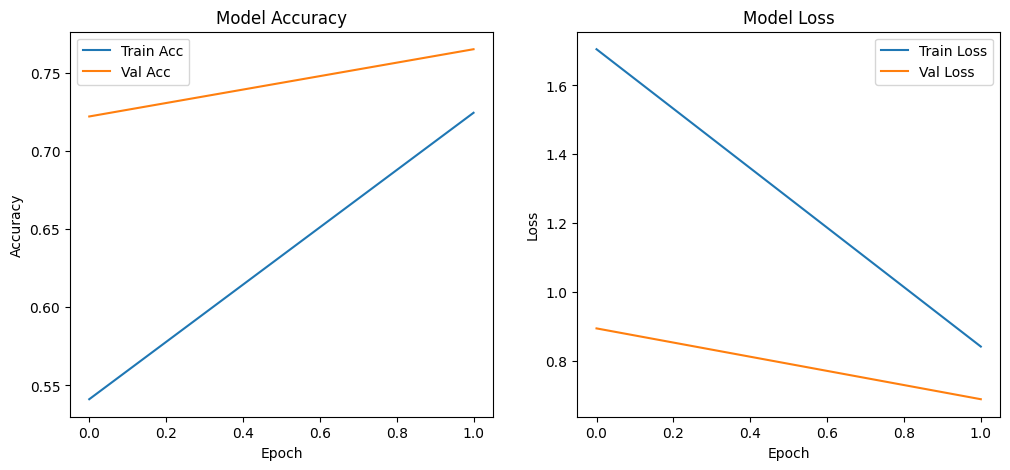

193/193 ━━━━━━━━━━━━━━━━━━━━ 137s 713ms/step - accuracy: 0.7609 - loss: 0.6850
🧪 Test Accuracy: 0.76


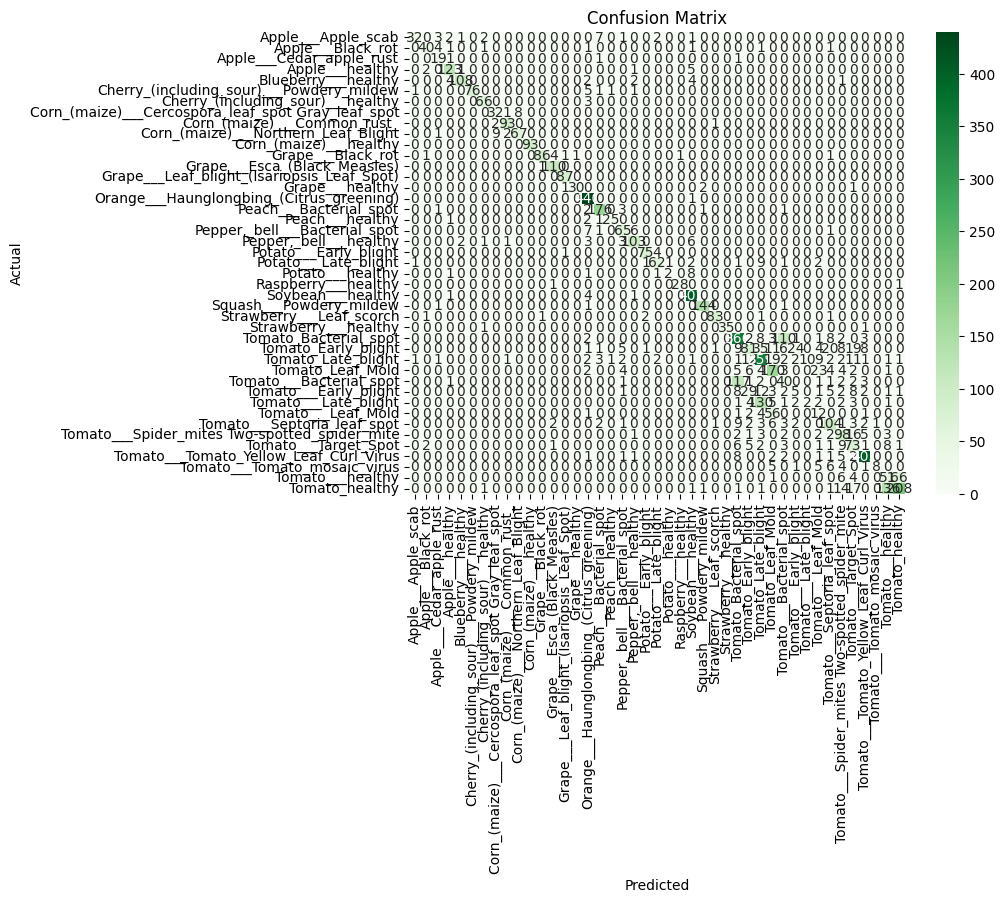

                                                    precision    recall  f1-score   support

                                Apple___Apple_scab       0.91      0.63      0.74        51
                                 Apple___Black_rot       0.87      0.80      0.83        50
                          Apple___Cedar_apple_rust       0.63      0.86      0.73        22
                                   Apple___healthy       0.91      0.93      0.92       132
                               Blueberry___healthy       0.96      0.89      0.93       121
          Cherry_(including_sour)___Powdery_mildew       1.00      0.89      0.94        85
                 Cherry_(including_sour)___healthy       0.92      0.96      0.94        69
Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot       0.74      0.78      0.76        41
                       Corn_(maize)___Common_rust_       0.95      0.97      0.96        96
               Corn_(maize)___Northern_Leaf_Blight       0.89      0.85      0.

In [1]:
# --- 1. Imports ---
%matplotlib inline
import os
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.models import load_model
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout
from tensorflow.keras.models import Sequential
from tensorflow.keras.optimizers import Adam
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix

# --- 2. Paths ---
train_dir = "../data/processed/train"
val_dir = "../data/processed/val"
test_dir = "../data/processed/test"

# --- 3. Data Generators ---
img_size = (224, 224)
batch_size = 32

train_gen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    zoom_range=0.2,
    horizontal_flip=True
)

val_gen = ImageDataGenerator(rescale=1./255)
test_gen = ImageDataGenerator(rescale=1./255)

train_data = train_gen.flow_from_directory(
    train_dir, target_size=img_size,
    batch_size=batch_size, class_mode='categorical'
)

val_data = val_gen.flow_from_directory(
    val_dir, target_size=img_size,
    batch_size=batch_size, class_mode='categorical'
)

test_data = test_gen.flow_from_directory(
    test_dir, target_size=img_size,
    batch_size=batch_size, class_mode='categorical',
    shuffle=False
)

num_classes = len(train_data.class_indices)
print("Number of Classes:", num_classes)
print("Train images:", train_data.samples)
print("Val images:", val_data.samples)
print("Test images:", test_data.samples)

# --- 4. Build Model ---
base_model = MobileNetV2(include_top=False, weights='imagenet', input_shape=img_size + (3,))
base_model.trainable = False

model = Sequential([
    base_model,
    GlobalAveragePooling2D(),
    Dropout(0.3),
    Dense(128, activation='relu'),
    Dense(num_classes, activation='softmax')
])

model.compile(
    optimizer=Adam(learning_rate=0.0001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()  # Display model architecture

# --- 5. Train Model ---
history = model.fit(
    train_data,
    validation_data=val_data,
    epochs=2,       # Change to 2 for quick test
    verbose=1        # Show progress in notebook
)

# --- 6. Save Model ---
os.makedirs("../models", exist_ok=True)
model.save("../models/best_model.h5")
print("✅ Model saved at ../models/best_model.h5")

# --- 7. Plot Accuracy and Loss ---
plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.plot(history.history['accuracy'], label='Train Acc')
plt.plot(history.history['val_accuracy'], label='Val Acc')
plt.title("Model Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()

plt.subplot(1,2,2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.title("Model Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()

plt.show()

# --- 8. Evaluate on Test Data ---
test_loss, test_acc = model.evaluate(test_data, verbose=1)
print(f"🧪 Test Accuracy: {test_acc:.2f}")

# --- 9. Confusion Matrix ---
y_true = test_data.classes
y_pred = np.argmax(model.predict(test_data, verbose=0), axis=1)

cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(8,6))
sns.heatmap(
    cm, annot=True, fmt='d', cmap='Greens',
    xticklabels=list(train_data.class_indices.keys()),
    yticklabels=list(train_data.class_indices.keys())
)
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

# --- 10. Classification Report ---
print(classification_report(y_true, y_pred, target_names=list(train_data.class_indices.keys())))
